In [31]:
# 04_ltv
#
# 목적: 근사 LTV(Lifetime Value)를 계산하고, 이미 학습한 LightGBM 이탈확률과 결합해
#      "Retention Priority"(누구를 먼저 케어해야 하는가) 세그먼트를 만든다.
#
# 중요 — 이 LTV는 근사치다 (생존분석 아님):
#   - avg_monthly_revenue = (총 결제액 / 결제 횟수)를 마지막 결제 플랜 일수(last_payment_plan_days)
#     기준으로 30일 환산한 값. [수정 이력] 원래는 "총 결제액 / 결제 횟수"를 그대로 "월평균"이라
#     불렀는데, payment_plan_days가 7/90/365일 등 30일이 아닌 플랜도 많아 실제로는 "결제 1건당
#     평균 금액"에 가까웠다. 마지막 플랜 일수로 나눠 30일 기준으로 정규화해 실제 월 환산 매출에
#     더 가깝게 고쳤다 (여전히 근사치이며, 유저가 플랜을 바꾼 이력까지 반영하지는 못한다).
#   - expected_lifetime = 1 / 이탈확률 (구독 이탈이 매달 동일 확률로 일어난다는 "상수 이탈률" 가정의
#     단순 공식. Kaplan-Meier 같은 생존분석 기법을 쓰지 않은 근사치이며, 극단적으로 낮은 이탈확률에서
#     수명이 비현실적으로 길어지는 것을 막기 위해 하한(1%)과 상한(60개월)을 둔다)
#   - ltv_approx는 참고 지표로 계산은 하되, 세그먼트 분류의 "가치" 축으로는 쓰지 않는다.
#     이유는 아래 세그먼트 계산 셀의 주석 참고 (churn_proba와 순환 종속되는 문제 발견)
#
# 세그먼트 분류: 이탈확률(risk)은 F1-최적 threshold, 가치(value)는 avg_monthly_revenue 중앙값 기준
# (두 축을 독립적으로 유지 — 자세한 이유는 세그먼트 계산 셀 참고)
#
# 입력: data/processed/frontend_customer_predictions.csv, features_transactions.csv,
#      models/lightgbm_enhanced_v2_meta.json
# 출력: 시각화, data/dashboard/customer_ltv_segments.csv (DB 적재 원천)

In [32]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
DASH_DATA = Path("../data/dashboard")
DASH_DATA.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
QUADRANT_COLORS = {
    "고위험/고월매출": "#e34948",
    "고위험/저월매출": "#eda100",
    "저위험/고월매출": "#1baf7a",
    "저위험/저월매출": "#2a78d6",
}
SERIES_1 = "#2a78d6"

CHURN_PROBA_FLOOR = 0.01
LIFETIME_CAP_MONTHS = 60

In [33]:
predictions = pd.read_csv(
    PROCESSED_DIR / "frontend_customer_predictions.csv",
    usecols=[
        "msno", "split", "is_churn", "churn_probability",
        "total_amount_paid", "txn_count",
        "days_to_expire", "days_since_last_txn",
    ],
)
assert len(predictions) == 148940
assert predictions["split"].eq("test").all()
assert predictions["msno"].duplicated().sum() == 0
predictions = predictions.rename(columns={"churn_probability": "churn_proba"})
print(f"Test 고객: {len(predictions):,}, 평균 예측 이탈확률: {predictions['churn_proba'].mean():.4f}")

Test 고객: 148,940, 평균 예측 이탈확률: 0.0640


In [34]:
txn_plan = pd.read_csv(
    PROCESSED_DIR / "features_transactions.csv",
    usecols=["msno", "last_payment_plan_days"],
)
ltv_df = predictions.merge(txn_plan, on="msno", how="left")
ltv_df["last_payment_plan_days"] = ltv_df["last_payment_plan_days"].fillna(30)
ltv_df["avg_revenue_per_txn"] = ltv_df["total_amount_paid"] / ltv_df["txn_count"].clip(lower=1)
# last_payment_plan_days가 30일이 아닌 유저(7일/90일/연간 등)를 그대로 "월평균"으로 부르면 왜곡되므로,
# 마지막 플랜 일수 기준으로 30일 환산한다. 0일짜리 이상치(전체의 0.7%)는 실제 관측된 최소 유효
# 플랜(7일)로 바닥을 둬서 나눗셈 폭주를 막는다.
plan_days_for_norm = ltv_df["last_payment_plan_days"].clip(lower=7)
ltv_df["avg_monthly_revenue"] = ltv_df["avg_revenue_per_txn"] / (plan_days_for_norm / 30)

ltv_df["churn_proba_floored"] = ltv_df["churn_proba"].clip(lower=CHURN_PROBA_FLOOR)
ltv_df["expected_lifetime_months"] = (1 / ltv_df["churn_proba_floored"]).clip(upper=LIFETIME_CAP_MONTHS)
ltv_df["ltv_approx"] = ltv_df["avg_monthly_revenue"] * ltv_df["expected_lifetime_months"]

print(f"LTV 분석 대상 Test 고객: {len(ltv_df):,}명")
print(ltv_df[["avg_revenue_per_txn", "avg_monthly_revenue", "expected_lifetime_months", "ltv_approx"]].describe())

LTV 분석 대상 Test 고객: 148,940명
       avg_revenue_per_txn  avg_monthly_revenue  expected_lifetime_months  \
count        148940.000000        148940.000000             148940.000000   
mean            148.138403           133.783511                 44.222490   
std             143.415864            66.860554                 21.159774   
min               0.000000             0.000000                  1.002117   
25%              99.000000            99.000000                 27.251643   
50%             139.769231           137.538462                 60.000000   
75%             149.000000           149.000000                 60.000000   
max            2000.000000          2950.714286                 60.000000   

          ltv_approx  
count  148940.000000  
mean     5669.820526  
std      3146.327762  
min         0.000000  
25%      3619.165354  
50%      5940.000000  
75%      8028.588120  
max     59040.000000  


In [35]:
with open(MODELS_DIR / "lightgbm_enhanced_v2_meta.json", encoding="utf-8") as f:
    model_meta = json.load(f)

# "고위험" 기준: population median 대신 모델의 F1-최적 threshold를 사용한다.
# 이유: churn_proba 분포가 심하게 치우쳐 있어(중앙값 0.012, 평균 0.107, 최대 0.998) median split을 쓰면
# 절대적으로는 위험하지 않은 유저(확률 1~2%)까지 "고위험"으로 분류되는 문제가 있었다.
# threshold는 Enhanced v2 Validation F1을 최대화하도록 선택한 값이다.
#
# "가치" 기준: ltv_approx 대신 avg_monthly_revenue(현재 월평균 매출)를 사용한다.
# 이유: ltv_approx = 매출 x (1/이탈확률)이라서 고위험 유저는 기대수명이 구조적으로 짧아지고,
# 그 결과 아무리 매출이 높아도 population 전체의 ltv_approx 중앙값을 못 넘는 문제가 실제로 발생했다
# (고위험/고가치 세그먼트가 0명으로 나옴). 위험도와 현재 월매출을 서로 독립적인 축으로 봐야
# 두 축을 곱해서 만든 파생 지표(ltv_approx)로 다시 축을 나누는 순환 논리를 피할 수 있다.
RISK_THRESHOLD = model_meta["threshold"]
revenue_median = ltv_df["avg_monthly_revenue"].median()

ltv_df["risk_tier"] = np.where(ltv_df["churn_proba"] >= RISK_THRESHOLD, "고위험", "저위험")
ltv_df["revenue_tier"] = np.where(ltv_df["avg_monthly_revenue"] >= revenue_median, "고월매출", "저월매출")
ltv_df["segment"] = ltv_df["risk_tier"] + "/" + ltv_df["revenue_tier"]
print(f"고위험 기준 threshold: {RISK_THRESHOLD:.4f}, 고월매출 기준 중앙값: {revenue_median:.1f} NTD")
print(ltv_df["segment"].value_counts())

OUTPUT_COLS = [
    "msno", "churn_proba", "risk_tier", "revenue_tier", "segment",
    "avg_monthly_revenue", "expected_lifetime_months", "ltv_approx",
    "days_to_expire", "days_since_last_txn",
]
ltv_df[OUTPUT_COLS].to_csv(DASH_DATA / "customer_ltv_segments.csv", index=False)
print(f"DB 적재 원천 저장: {DASH_DATA / 'customer_ltv_segments.csv'}")

고위험 기준 threshold: 0.2851, 고월매출 기준 중앙값: 137.5 NTD
segment
저위험/저월매출    69725
저위험/고월매출    69394
고위험/고월매출     5348
고위험/저월매출     4473
Name: count, dtype: int64
DB 적재 원천 저장: ..\data\dashboard\customer_ltv_segments.csv


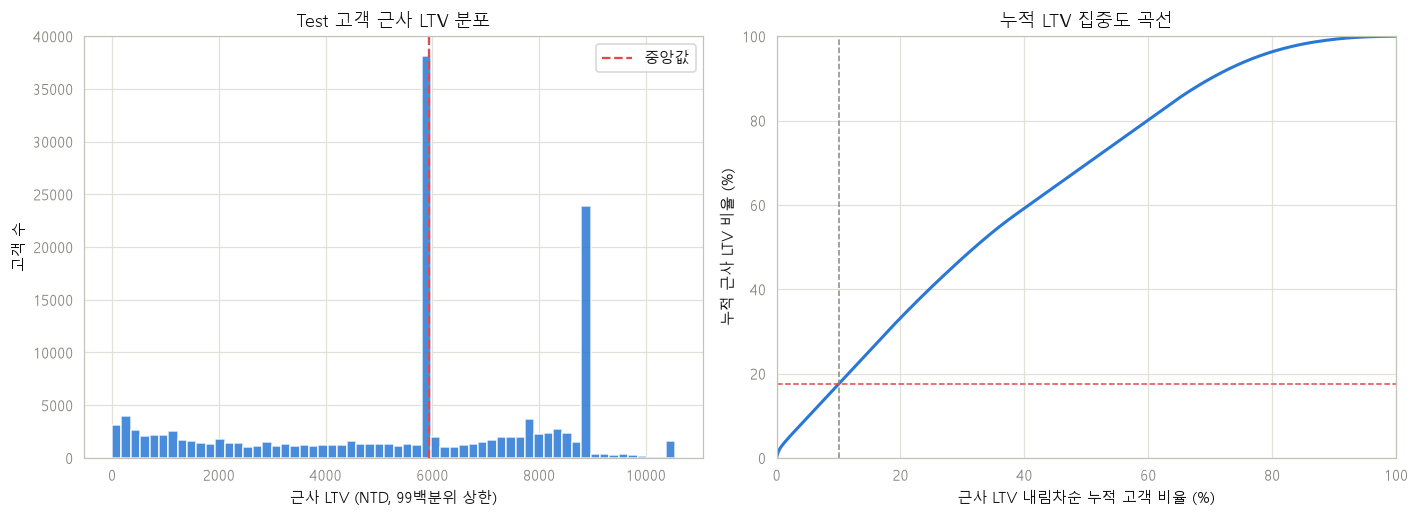

근사 LTV 중앙값: 5,940.0 NTD
근사 LTV 90백분위: 8,940.0 NTD
근사 LTV 99백분위: 10,547.9 NTD
상위 10% 고객의 누적 LTV 비중: 17.5%


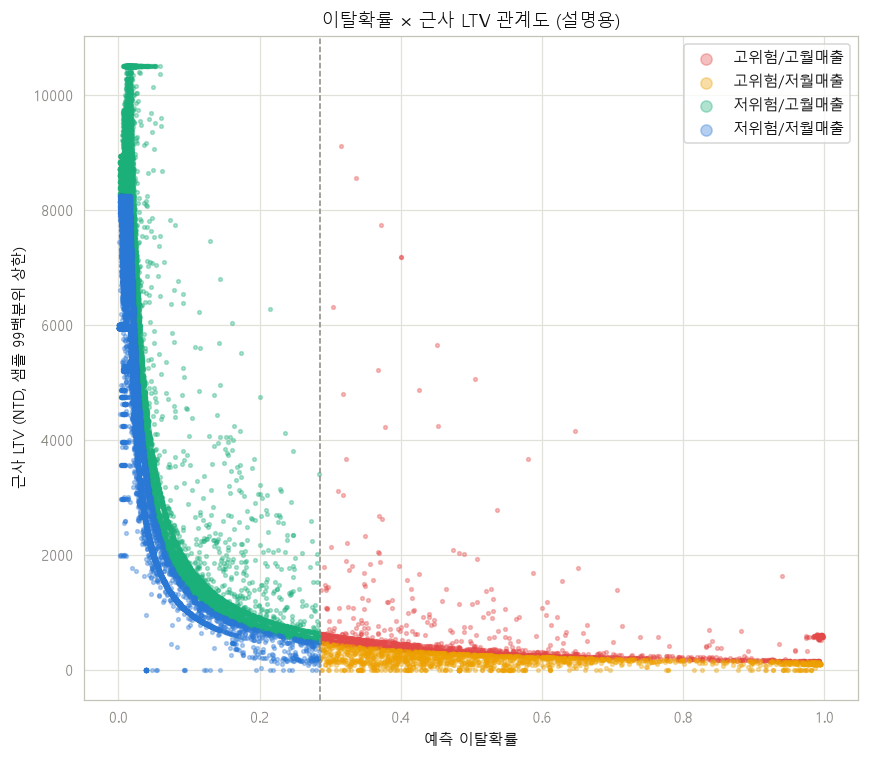

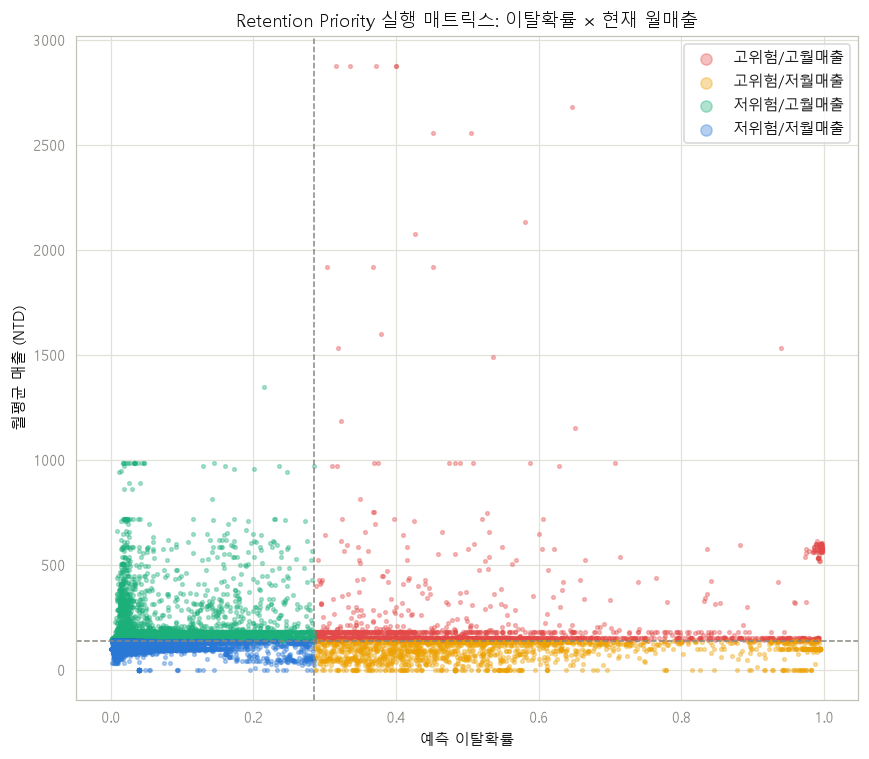

In [36]:
# LTV 분포와 누적 집중도 곡선
valid_ltv = ltv_df.loc[
    np.isfinite(ltv_df["ltv_approx"]) & (ltv_df["ltv_approx"] >= 0),
    "ltv_approx",
]
ltv_p99 = valid_ltv.quantile(0.99)
ltv_clipped = valid_ltv.clip(upper=ltv_p99)

sorted_ltv = valid_ltv.sort_values(ascending=False).reset_index(drop=True)
customer_pct = (np.arange(1, len(sorted_ltv) + 1) / len(sorted_ltv)) * 100
cumulative_ltv_pct = (sorted_ltv.cumsum() / sorted_ltv.sum()) * 100
top_10_ltv_share = cumulative_ltv_pct.iloc[max(int(len(sorted_ltv) * 0.10) - 1, 0)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hist(ltv_clipped, bins=60, color=SERIES_1, alpha=0.85)
axes[0].axvline(valid_ltv.median(), color="#e34948", linestyle="--", label="중앙값")
axes[0].set_xlabel("근사 LTV (NTD, 99백분위 상한)")
axes[0].set_ylabel("고객 수")
axes[0].set_title("Test 고객 근사 LTV 분포")
axes[0].legend()

axes[1].plot(customer_pct, cumulative_ltv_pct, color=SERIES_1, linewidth=2)
axes[1].axvline(10, color="#898781", linestyle="--", linewidth=1)
axes[1].axhline(top_10_ltv_share, color="#e34948", linestyle="--", linewidth=1)
axes[1].set_xlabel("근사 LTV 내림차순 누적 고객 비율 (%)")
axes[1].set_ylabel("누적 근사 LTV 비율 (%)")
axes[1].set_title("누적 LTV 집중도 곡선")
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)
axes[1].grid(True)
plt.tight_layout()
plt.show()

print(f"근사 LTV 중앙값: {valid_ltv.median():,.1f} NTD")
print(f"근사 LTV 90백분위: {valid_ltv.quantile(0.90):,.1f} NTD")
print(f"근사 LTV 99백분위: {ltv_p99:,.1f} NTD")
print(f"상위 10% 고객의 누적 LTV 비중: {top_10_ltv_share:.1f}%")

# 아래 산점도는 LTV 곡선이 아니라 마케팅 실행 우선순위 매트릭스다.
# 산점도가 너무 무거우니 시각화용으로만 5만 명 샘플링 (분석/집계는 전체 데이터로 이미 완료됨)
sample = ltv_df.sample(n=min(50_000, len(ltv_df)), random_state=42)

# 기존 대시보드에서 사용한 곡선형 관계도
# ltv_approx에 1/churn_proba가 포함되므로 두 변수는 수식상 역관계를 가진다.
# 관계 설명에는 유용하지만, 이 그래프 자체를 세그먼트 판정 기준으로 사용하지 않는다.
curve_y_max = sample["ltv_approx"].quantile(0.99)
fig, ax = plt.subplots(figsize=(8, 7))
for seg, color in QUADRANT_COLORS.items():
    sub = sample[sample["segment"] == seg]
    ax.scatter(
        sub["churn_proba"],
        sub["ltv_approx"].clip(upper=curve_y_max),
        s=6, alpha=0.35, color=color, label=seg,
    )
ax.axvline(RISK_THRESHOLD, color="#898781", linestyle="--", linewidth=1)
ax.set_xlabel("예측 이탈확률")
ax.set_ylabel("근사 LTV (NTD, 샘플 99백분위 상한)")
ax.set_title("이탈확률 × 근사 LTV 관계도 (설명용)")
ax.legend(markerscale=3, loc="upper right")
plt.tight_layout()
plt.show()

# 실제 마케팅 세그먼트 판정은 이탈확률과 독립적인 현재 월매출을 가치 축으로 사용한다.
fig, ax = plt.subplots(figsize=(8, 7))
for seg, color in QUADRANT_COLORS.items():
    sub = sample[sample["segment"] == seg]
    ax.scatter(sub["churn_proba"], sub["avg_monthly_revenue"], s=6, alpha=0.35, color=color, label=seg)

ax.axvline(RISK_THRESHOLD, color="#898781", linestyle="--", linewidth=1)
ax.axhline(revenue_median, color="#898781", linestyle="--", linewidth=1)
ax.set_xlabel("예측 이탈확률")
ax.set_ylabel("월평균 매출 (NTD)")
ax.set_title("Retention Priority 실행 매트릭스: 이탈확률 × 현재 월매출")
ax.legend(markerscale=3, loc="upper right")
plt.tight_layout()
plt.show()

In [37]:
# "고위험/고월매출" 세그먼트 예시 (실제 액션은 취하지 않음, 우선순위 후보군 식별 데모)
top_priority = (
    ltv_df[ltv_df["segment"] == "고위험/고월매출"]
    .sort_values("avg_monthly_revenue", ascending=False)
    .head(10)[["msno", "churn_proba", "avg_monthly_revenue", "expected_lifetime_months", "ltv_approx"]]
)
print(f"고위험/고월매출 세그먼트 규모: {(ltv_df['segment'] == '고위험/고월매출').sum():,}명")
top_priority

고위험/고월매출 세그먼트 규모: 5,348명


,msno,churn_proba,avg_monthly_revenue,expected_lifetime_months,ltv_approx
6547,YrjgyMaQmYgOSLk4oairoXEC+X7OUXpcJrstydYy8cw=,0.406352,2950.714286,2.460919,7261.468833
6684,8hKzliY/nDXQV3esmWjQoawAPDCsPjUgsZqBZ1TpkpY=,0.400295,2873.571429,2.498161,7178.643178
6681,9xmlMKleuGpAbUxpNVeAHlmmtg0n4ynPLzrEFbea3cM=,0.400490,2873.571429,2.496939,7175.133350
7438,Rilp7LE1W/uXWXQK9n0ZVxU30zsz8uLM8V9iQUyXPMA=,0.371585,2873.571429,2.691173,7733.277526
8415,P3AKjPZjgnPaltIzoFt+7jFTLZ/XhU1y2u2XWlgr1c8=,0.336037,2873.571429,2.975861,8551.350329
8959,bxD6v9RT6Qug0yEp2L9nTOLmgtRWAoSY7fNUYhVSxfE=,0.315233,2873.571429,3.172254,9115.697878
2375,FLMeD5uDqJEu47NvfeAXSodqUQNXkgq0zqMY6MQdH9k=,0.646984,2682.000000,1.545634,4145.391289
5403,6jT4eVWNN2Kwey7hrNXdbQyB0Hhyn92gXi7LvLsKNr0=,0.456816,2651.142857,2.189065,5803.524411
5552,jYz1u3nPNN+cxmgVqt9hilsRsTYxA4vpftHorlNhklg=,0.450042,2605.714286,2.222015,5789.936361
5512,V2bSpWIJ5fOFd3QLkVnioPCa3F84Alcc8b/RZnXG4dI=,0.451721,2554.285714,2.213754,5654.561148


In [38]:
# ------------------------------------------------------------------
# 해석 시 주의할 점
# 1. LTV는 "결제횟수=개월 수" 단순화 + "1/이탈확률" 상수 이탈률 근사 공식으로 계산한 추정치다.
#    Kaplan-Meier 등 생존분석 기반 정밀 LTV가 아니며, 방향성 참고용으로만 써야 한다.
# 2. 이탈확률은 LightGBM 모델의 예측값으로, 실제 이탈 여부가 아니다 (모델 성능만큼의 오차 존재).
# 3. "고위험/고월매출" 세그먼트 식별은 우선순위 후보군을 보여주는 데모이며, 실제 Retention Action을
#    수행하거나 그 효과를 측정한 것은 아니다.
# ------------------------------------------------------------------
print("LTV 및 Retention Priority 분석 완료 (위 주석의 해석 주의사항 참고)")

LTV 및 Retention Priority 분석 완료 (위 주석의 해석 주의사항 참고)
